In [69]:
import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# 한글 폰트 설정 (macOS)
import matplotlib.font_manager as fm
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 프로젝트 루트로 이동 (어느 위치에서 실행해도 동작)
PROJECT_ROOT = os.path.expanduser('~/Documents/projects/capstone_nlp')
os.chdir(PROJECT_ROOT)
print(f"CWD: {os.getcwd()}")

# CSV 로드
df_raw = pd.read_csv('hatexplain_prediction.csv')
print(f"전체 샘플 수: {len(df_raw)}")
print(df_raw.dtypes)

# ── 컬럼 리매핑 (이후 셀 전체에서 통일된 이름 사용) ──────────────────────
import ast as _ast

# 라벨: gold_hatexplain_label(int) → majority_label(str)
LABEL_MAP = {0: 'hatespeech', 1: 'normal', 2: 'offensive'}
df_raw['majority_label'] = df_raw['gold_hatexplain_label'].map(LABEL_MAP)

# 토큰: post_tokens → tokens
df_raw['tokens'] = df_raw['post_tokens']

# agreement: annotators 컬럼에서 label 배열 파싱
# 실제 형태: "{'label': array([0, 2, 2]), ...}" — numpy array 표현이라 ast 불가
import re as _re

def compute_agreement(ann_str):
    try:
        # 'label': array([0, 2, 2]) 에서 숫자 리스트만 추출
        m = _re.search(r"'label'\s*:\s*array\(\[([^\]]+)\]", ann_str)
        if m:
            labels = [int(x.strip()) for x in m.group(1).split(',')]
        else:
            # fallback: label 키 뒤 숫자들 직접 추출
            m2 = _re.search(r"'label'\s*:\s*\[([^\]]+)\]", ann_str)
            if m2:
                labels = [int(x.strip()) for x in m2.group(1).split(',')]
            else:
                return 'majority'
        counts = Counter(labels)
        top_count = counts.most_common(1)[0][1]
        if top_count == len(labels):   # 3명 만장일치
            return 'unanimous'
        elif top_count >= 2:           # 2:1 다수결
            return 'majority'
        else:                          # 1:1:1 삼분
            return 'split'
    except Exception:
        return 'majority'

df_raw['agreement'] = df_raw['annotators'].apply(compute_agreement)

print("\n=== 리매핑 결과 ===")
print(df_raw[['majority_label','agreement']].value_counts().sort_index())
df_raw.head(3)

CWD: /Users/imeanseo/Documents/projects/capstone_nlp
전체 샘플 수: 19229
split                        str
post_id                      str
id                           str
text                         str
post_tokens                  str
annotators                   str
rationales                   str
gold_hatexplain_label      int64
targets                      str
pred_label                   str
pred_label_id              int64
negative_prob            float64
positive_prob            float64
dtype: object

=== 리매핑 결과 ===
majority_label  agreement
hatespeech      majority     2975
                unanimous    2960
normal          majority     2690
                unanimous    5124
offensive       majority     3719
                unanimous    1761
Name: count, dtype: int64


,split,post_id,id,text,post_tokens,annotators,rationales,gold_hatexplain_label,targets,pred_label,pred_label_id,negative_prob,positive_prob,majority_label,tokens,agreement
0,train,23107796_gab,23107796_gab,u really think i would not have been raped by ...,['u' 'really' 'think' 'i' 'would' 'not' 'have'...,"{'label': array([0, 2, 2]), 'annotator_id': ar...","[array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,...",2,"['Hindu', 'Islam', 'Other']",positive,1,0.419202,0.580798,offensive,['u' 'really' 'think' 'i' 'would' 'not' 'have'...,majority
1,train,9995600_gab,9995600_gab,the uk has threatened to return radioactive wa...,['the' 'uk' 'has' 'threatened' 'to' 'return' '...,"{'label': array([2, 2, 0]), 'annotator_id': ar...","[array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",2,"['Indian', 'Islam', 'Minority', 'Refugee']",negative,0,0.745815,0.254185,offensive,['the' 'uk' 'has' 'threatened' 'to' 'return' '...,majority
2,train,1227920812235051008_twitter,1227920812235051008_twitter,if english is not imposition then hindi is als...,['if' 'english' 'is' 'not' 'imposition' 'then'...,"{'label': array([2, 2, 2]), 'annotator_id': ar...","[array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",2,"['Hindu', 'Other']",negative,0,0.988602,0.011398,offensive,['if' 'english' 'is' 'not' 'imposition' 'then'...,unanimous


In [70]:
# 라벨 분포
print("=== 라벨별 분포 ===")
print(df_raw['majority_label'].value_counts())
print(df_raw['majority_label'].value_counts(normalize=True).round(3))

# Agreement 분포
print("\n=== Agreement 분포 ===")
print(df_raw['agreement'].value_counts())
print(df_raw['agreement'].value_counts(normalize=True).round(3))

# 라벨 × Agreement 교차표
print("\n=== 라벨 × Agreement 교차표 ===")
print(pd.crosstab(df_raw['majority_label'], df_raw['agreement']))

=== 라벨별 분포 ===
majority_label
normal        7814
hatespeech    5935
offensive     5480
Name: count, dtype: int64
majority_label
normal        0.406
hatespeech    0.309
offensive     0.285
Name: proportion, dtype: float64

=== Agreement 분포 ===
agreement
unanimous    9845
majority     9384
Name: count, dtype: int64
agreement
unanimous    0.512
majority     0.488
Name: proportion, dtype: float64

=== 라벨 × Agreement 교차표 ===
agreement       majority  unanimous
majority_label                     
hatespeech          2975       2960
normal              2690       5124
offensive           3719       1761


토큰 파싱 확인 (첫 번째 샘플 앞 10개): ['u', 'really', 'think', 'i', 'would', 'not', 'have', 'been', 'raped', 'by']
=== 전체 토큰 수 기술통계 ===
count    19229.000000
mean        23.432160
std         13.786932
min          2.000000
5%           5.000000
10%          7.000000
25%         12.000000
50%         20.000000
75%         34.000000
90%         45.000000
95%         49.000000
max        165.000000
Name: n_tokens, dtype: float64

=== 라벨별 토큰 수 중앙값 ===
majority_label
hatespeech    22.0
normal        20.0
offensive     19.0
Name: n_tokens, dtype: float64


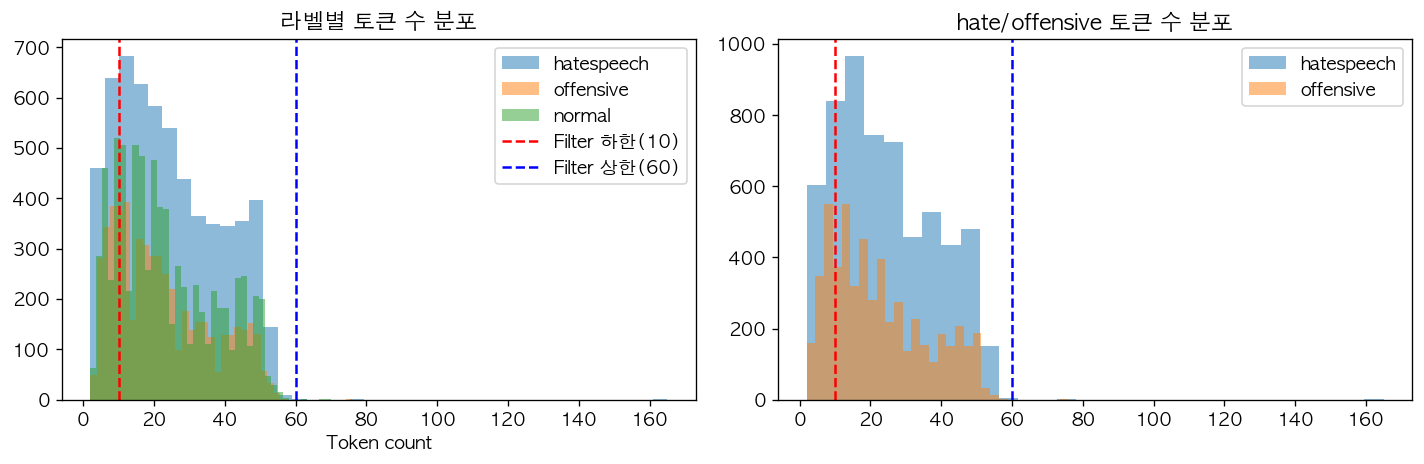


hate/offensive 전체: 11415
Filter 2(10~60) 통과: 9413 (82.5%)


In [71]:
import ast

import re as _re2

def parse_token_col(x):
    """numpy array repr ['word1' 'word2' ...] 또는 일반 list str 모두 처리"""
    if isinstance(x, list):
        return x
    s = str(x)
    tokens = _re2.findall(r"'([^']*?)'", s)  # 'word' 패턴에서 단어만 추출
    return [t for t in tokens if t.strip()]   # 빈 문자열 제거

df_raw['tokens_list'] = df_raw['post_tokens'].apply(parse_token_col)
print(f"토큰 파싱 확인 (첫 번째 샘플 앞 10개): {df_raw['tokens_list'].iloc[0][:10]}")

df_raw['n_tokens'] = df_raw['tokens_list'].apply(len)

# 라벨별 토큰 수 분포
print("=== 전체 토큰 수 기술통계 ===")
print(df_raw['n_tokens'].describe(percentiles=[.05, .1, .25, .5, .75, .9, .95]))

print("\n=== 라벨별 토큰 수 중앙값 ===")
print(df_raw.groupby('majority_label')['n_tokens'].median())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for label in ['hatespeech', 'offensive', 'normal']:
    subset = df_raw[df_raw['majority_label'] == label]['n_tokens']
    axes[0].hist(subset, bins=40, alpha=0.5, label=label)
axes[0].axvline(10, color='red', linestyle='--', label='Filter 하한(10)')
axes[0].axvline(60, color='blue', linestyle='--', label='Filter 상한(60)')
axes[0].set_title('라벨별 토큰 수 분포')
axes[0].legend()
axes[0].set_xlabel('Token count')

# hate/offensive만 상세
hate_off = df_raw[df_raw['majority_label'].isin(['hatespeech', 'offensive'])]
for label in ['hatespeech', 'offensive']:
    subset = hate_off[hate_off['majority_label'] == label]['n_tokens']
    axes[1].hist(subset, bins=30, alpha=0.5, label=label)
axes[1].axvline(10, color='red', linestyle='--')
axes[1].axvline(60, color='blue', linestyle='--')
axes[1].set_title('hate/offensive 토큰 수 분포')
axes[1].legend()
plt.tight_layout()
plt.show()

# Filter 2 적용 시 커버리지 확인
hate_off_filtered = hate_off[(hate_off['n_tokens'] >= 10) & (hate_off['n_tokens'] <= 60)]
print(f"\nhate/offensive 전체: {len(hate_off)}")
print(f"Filter 2(10~60) 통과: {len(hate_off_filtered)} ({len(hate_off_filtered)/len(hate_off)*100:.1f}%)")

파싱 확인 (1번째 행): ['Hindu', 'Islam', 'Other']
타입 확인: <class 'list'>
빈 리스트 수: 0
=== 전체 타겟 빈도 ===
  None: 10183
  African: 4253
  Women: 3726
  Other: 3487
  Islam: 2992
  Homosexual: 2472
  Jewish: 2396
  Arab: 1661
  Caucasian: 1594
  Men: 1539
  Refugee: 1534
  Asian: 675
  Hispanic: 663
  Christian: 190
  Minority: 188
  Disability: 153
  Heterosexual: 136
  Nonreligious: 86
  Economic: 79
  Indigenous: 74
  Indian: 70
  Hindu: 60
  Buddhism: 10
  Bisexual: 8
  Asexual: 5

=== 타겟별 라벨 비율 ===
label         hatespeech  normal  offensive
target                                     
African            0.602   0.155      0.243
Arab               0.600   0.115      0.285
Asexual            1.000   0.000      0.000
Asian              0.421   0.270      0.310
Bisexual           0.250   0.125      0.625
Buddhism           0.100   0.100      0.800
Caucasian          0.267   0.355      0.378
Christian          0.347   0.305      0.347
Disability         0.412   0.170      0.418
Economic           0.

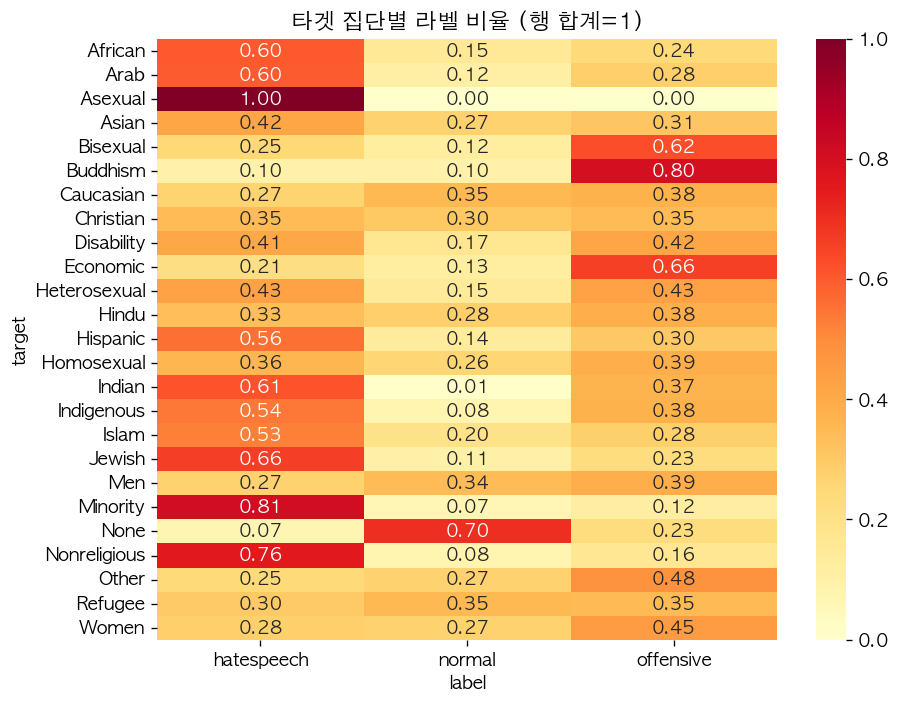

In [72]:
import ast as _ast3

def parse_targets_col(x):
    """targets 컬럼 파싱 — ['Hindu', 'Islam'] 형태 문자열 → 파이썬 리스트"""
    if isinstance(x, list):
        return x
    if not isinstance(x, str):
        return []
    try:
        result = _ast3.literal_eval(x.strip())
        if isinstance(result, list):
            return result
        return [str(result)]  # 단일값인 경우
    except Exception:
        return []

df_raw['targets_list'] = df_raw['targets'].apply(parse_targets_col)

# 파싱 검증
print(f"파싱 확인 (1번째 행): {df_raw['targets_list'].iloc[0]}")
print(f"타입 확인: {type(df_raw['targets_list'].iloc[0])}")
print(f"빈 리스트 수: {(df_raw['targets_list'].apply(len) == 0).sum()}")

# 전체 타겟 빈도
all_targets = [t for ts in df_raw['targets_list'] for t in ts]
target_counts = Counter(all_targets)
print("=== 전체 타겟 빈도 ===")
for t, c in target_counts.most_common():
    print(f"  {t}: {c}")

# 라벨별 타겟 분포 (heatmap)
target_label_rows = []
for _, row in df_raw.iterrows():
    for t in set(row['targets_list']):
        target_label_rows.append({'target': t, 'label': row['majority_label']})
tl_df = pd.DataFrame(target_label_rows)
tl_pivot = pd.crosstab(tl_df['target'], tl_df['label'])
tl_pivot_pct = tl_pivot.div(tl_pivot.sum(axis=1), axis=0).round(3)

print("\n=== 타겟별 라벨 비율 ===")
print(tl_pivot_pct)

plt.figure(figsize=(8, 6))
sns.heatmap(tl_pivot_pct, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('타겟 집단별 라벨 비율 (행 합계=1)')
plt.tight_layout()
plt.show()

In [73]:
print(type(df_raw['targets'].iloc[0]))
print(repr(df_raw['targets'].iloc[0]))

<class 'str'>
"['Hindu', 'Islam', 'Other']"


=== 타겟별 unanimous 비율 (hate/offensive) ===
target
Asexual         1.000
Nonreligious    0.759
Bisexual        0.714
Minority        0.651
Economic        0.623
Disability      0.575
Indian          0.507
Jewish          0.503
African         0.464
Indigenous      0.456
Homosexual      0.423
Heterosexual    0.422
Women           0.397
Hispanic        0.396
Other           0.389
Arab            0.388
Christian       0.371
Islam           0.365
Caucasian       0.345
Buddhism        0.333
Men             0.332
Asian           0.327
Hindu           0.326
Refugee         0.291
None            0.210
Name: is_unanimous, dtype: float64


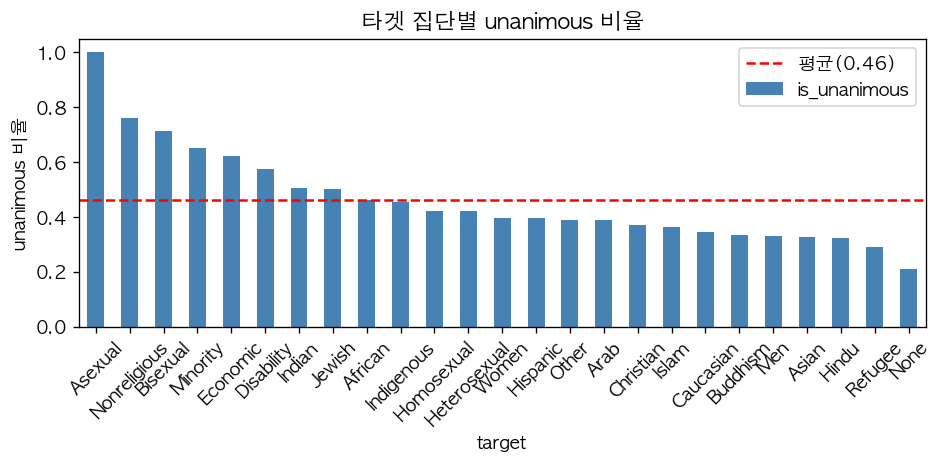

In [90]:
# 타겟 집단별 unanimous 비율 (hate/offensive만)
hate_off = hate_off.copy()  # SettingWithCopyWarning 방지

target_agreement_rows = []
for _, row in hate_off.iterrows():
    for t in set(row['targets_list']):
        target_agreement_rows.append({
            'target': t,
            'is_unanimous': int(row['agreement'] == 'unanimous')
        })
ta_df = pd.DataFrame(target_agreement_rows)
unanimous_rate = ta_df.groupby('target')['is_unanimous'].mean().sort_values(ascending=False)

print("=== 타겟별 unanimous 비율 (hate/offensive) ===")
print(unanimous_rate.round(3))

plt.figure(figsize=(8, 4))
unanimous_rate.plot(kind='bar', color='steelblue')
plt.axhline(unanimous_rate.mean(), color='red', linestyle='--', label=f'평균({unanimous_rate.mean():.2f})')
plt.title('타겟 집단별 unanimous 비율')
plt.ylabel('unanimous 비율')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

        n_tokens  n_targets  vader_neg  vader_compound  label_binary  \
count  11415.000  11415.000  11415.000       11415.000      11415.00   
mean      23.509      1.946      0.216          -0.322          0.52   
std       13.861      1.147      0.176           0.520          0.50   
min        2.000      0.000      0.000          -1.000          0.00   
25%       12.000      1.000      0.082          -0.770          0.00   
50%       21.000      2.000      0.194          -0.494          1.00   
75%       34.000      2.000      0.319           0.000          1.00   
max      165.000     13.000      1.000           0.995          1.00   

       unanimous  
count  11415.000  
mean       0.414  
std        0.492  
min        0.000  
25%        0.000  
50%        0.000  
75%        1.000  
max        1.000  

=== Spearman 상관계수 행렬 ===
                n_tokens  n_targets  vader_neg  vader_compound  label_binary  \
n_tokens           1.000      0.200     -0.222          -0.092         0.0

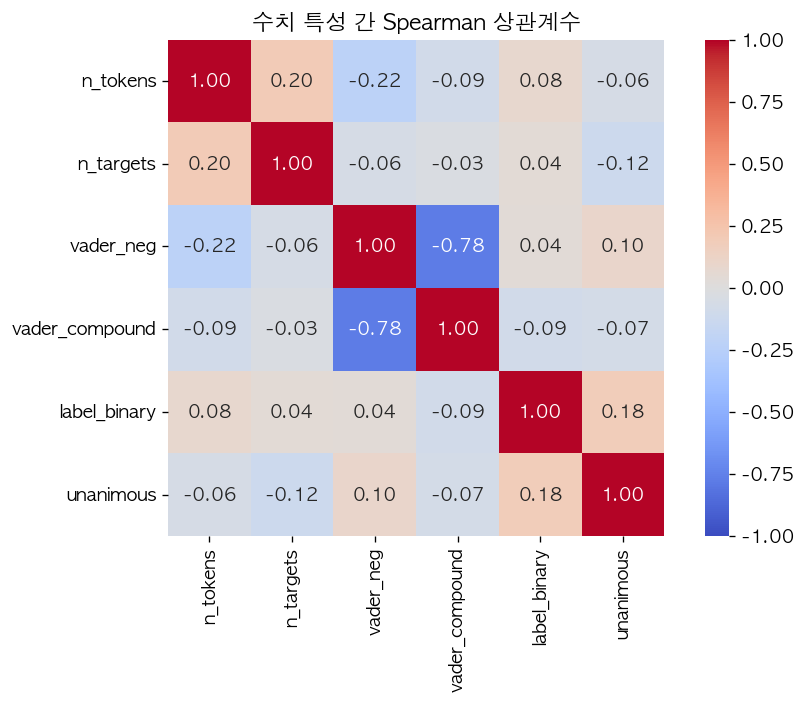

In [91]:
import spacy
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

nlp = spacy.load('en_core_web_sm')
vader = SentimentIntensityAnalyzer()

# 분석 대상: hate/offensive
analysis_df = hate_off.copy().reset_index(drop=True)

def compute_features(row):
    tokens = [t.lower() for t in row['tokens_list']]
    text = ' '.join(tokens)
    return pd.Series({
        'n_tokens':   len(tokens),
        'n_targets':  len([t for t in row['targets_list'] if t != 'Other']),
        'vader_neg':  vader.polarity_scores(text)['neg'],
        'vader_compound': vader.polarity_scores(text)['compound'],
        'label_binary': 1 if row['majority_label'] == 'hatespeech' else 0,
        'unanimous':  1 if row['agreement'] == 'unanimous' else 0,
    })

features = analysis_df.apply(compute_features, axis=1)
print(features.describe().round(3))

# 상관관계 행렬
corr = features.corr(method='spearman').round(3)
print("\n=== Spearman 상관계수 행렬 ===")
print(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True)
plt.title('수치 특성 간 Spearman 상관계수')
plt.tight_layout()
plt.show()

=== hatespeech vs. offensive 평균 비교 ===
n_tokens             | hate: 24.568 | offensive: 22.362 | p=0.0000 ***
n_targets            | hate: 2.002 | offensive: 1.885 | p=0.0000 ***
vader_neg            | hate: 0.222 | offensive: 0.209 | p=0.0000 ***
vader_compound       | hate: -0.358 | offensive: -0.283 | p=0.0000 ***
unanimous            | hate: 0.499 | offensive: 0.321 | p=0.0000 ***


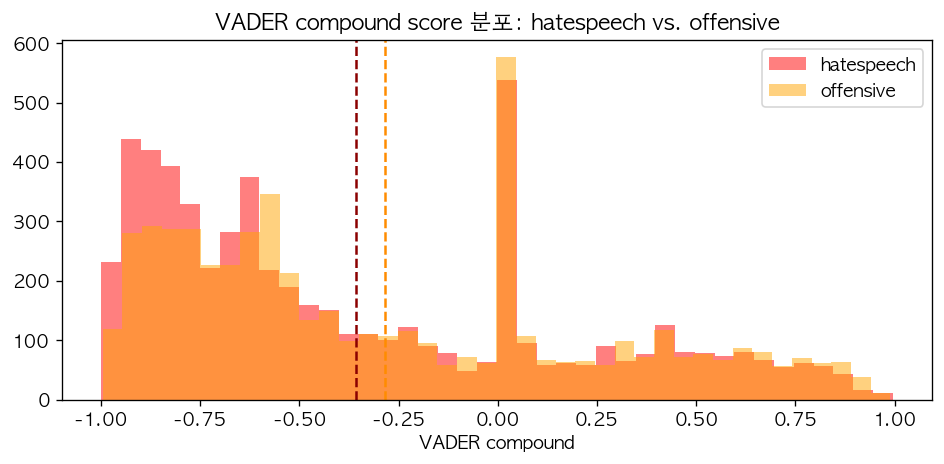

In [92]:
hate = features[features['label_binary'] == 1]
offensive = features[features['label_binary'] == 0]

print("=== hatespeech vs. offensive 평균 비교 ===")
for col in ['n_tokens', 'n_targets', 'vader_neg', 'vader_compound', 'unanimous']:
    t_stat, p_val = stats.mannwhitneyu(hate[col], offensive[col], alternative='two-sided')
    print(f"{col:20s} | hate: {hate[col].mean():.3f} | offensive: {offensive[col].mean():.3f} | p={p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''}")

# VADER compound 분포 시각화
plt.figure(figsize=(8, 4))
plt.hist(hate['vader_compound'], bins=40, alpha=0.5, label='hatespeech', color='red')
plt.hist(offensive['vader_compound'], bins=40, alpha=0.5, label='offensive', color='orange')
plt.axvline(hate['vader_compound'].mean(), color='darkred', linestyle='--')
plt.axvline(offensive['vader_compound'].mean(), color='darkorange', linestyle='--')
plt.title('VADER compound score 분포: hatespeech vs. offensive')
plt.xlabel('VADER compound')
plt.legend()
plt.tight_layout()
plt.show()

=== 타겟 집단 공동 출현 횟수 ===
                  African  Islam  Jewish  Women  Refugee  Homosexual  Arab  \
African                 0    357     457    803      170         365   397   
Islam                 357      0     339    401      350         171  1022   
Jewish                457    339       0    299       98         257   253   
Women                 803    401     299      0      182         464   303   
Refugee               170    350      98    182        0          51   244   
Homosexual            365    171     257    464       51           0   104   
Arab                  397   1022     253    303      244         104     0   
Latino_Americans        0      0       0      0        0           0     0   
Asian                 163     79      78     70       58          33   125   

                  Latino_Americans  Asian  
African                          0    163  
Islam                            0     79  
Jewish                           0     78  
Women               

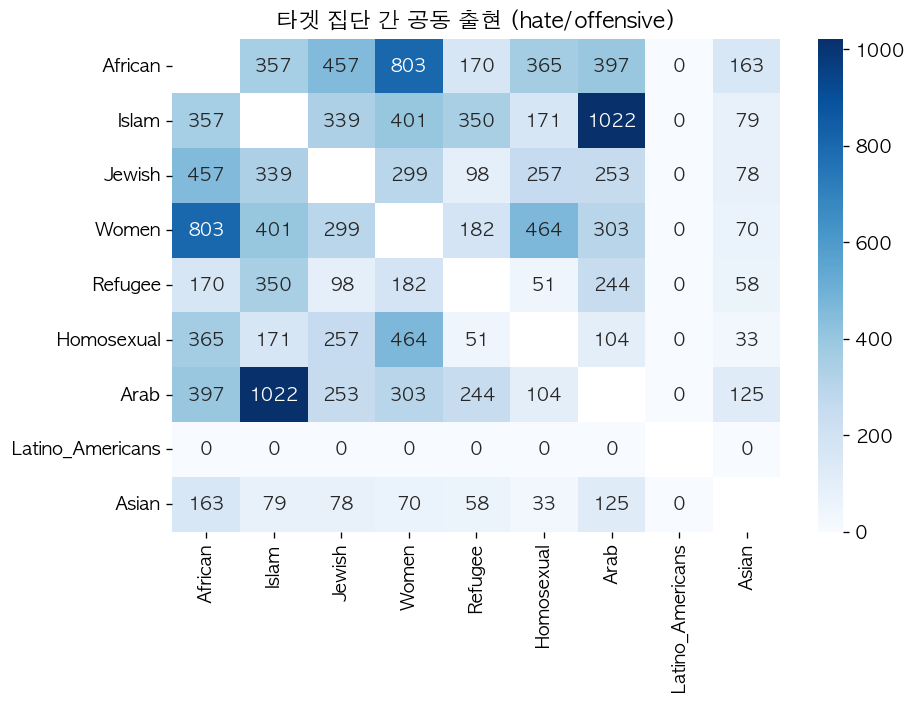


=== 유효 타겟 수 분포 ===
targets_list
0    1324
1    6088
2    2878
3     794
4     258
5      52
6      15
7       4
8       2
Name: count, dtype: int64


In [93]:
VALID_GROUPS = ['African', 'Islam', 'Jewish', 'Women',
                'Refugee', 'Homosexual', 'Arab', 'Latino_Americans', 'Asian']

# 공동 출현 행렬
cooccur = pd.DataFrame(0, index=VALID_GROUPS, columns=VALID_GROUPS)
for _, row in hate_off.iterrows():
    valid_tgts = [t for t in set(row['targets_list']) if t in VALID_GROUPS]
    for i, t1 in enumerate(valid_tgts):
        for t2 in valid_tgts[i:]:
            if t1 != t2:
                cooccur.loc[t1, t2] += 1
                cooccur.loc[t2, t1] += 1

print("=== 타겟 집단 공동 출현 횟수 ===")
print(cooccur)

plt.figure(figsize=(8, 6))
mask = np.eye(len(VALID_GROUPS), dtype=bool)
sns.heatmap(cooccur, annot=True, fmt='d', cmap='Blues', mask=mask)
plt.title('타겟 집단 간 공동 출현 (hate/offensive)')
plt.tight_layout()
plt.show()

# 타겟 수 분포 (1개 vs 2개 vs 3개+)
n_target_dist = hate_off['targets_list'].apply(
    lambda ts: len([t for t in ts if t in VALID_GROUPS])
).value_counts().sort_index()
print("\n=== 유효 타겟 수 분포 ===")
print(n_target_dist)

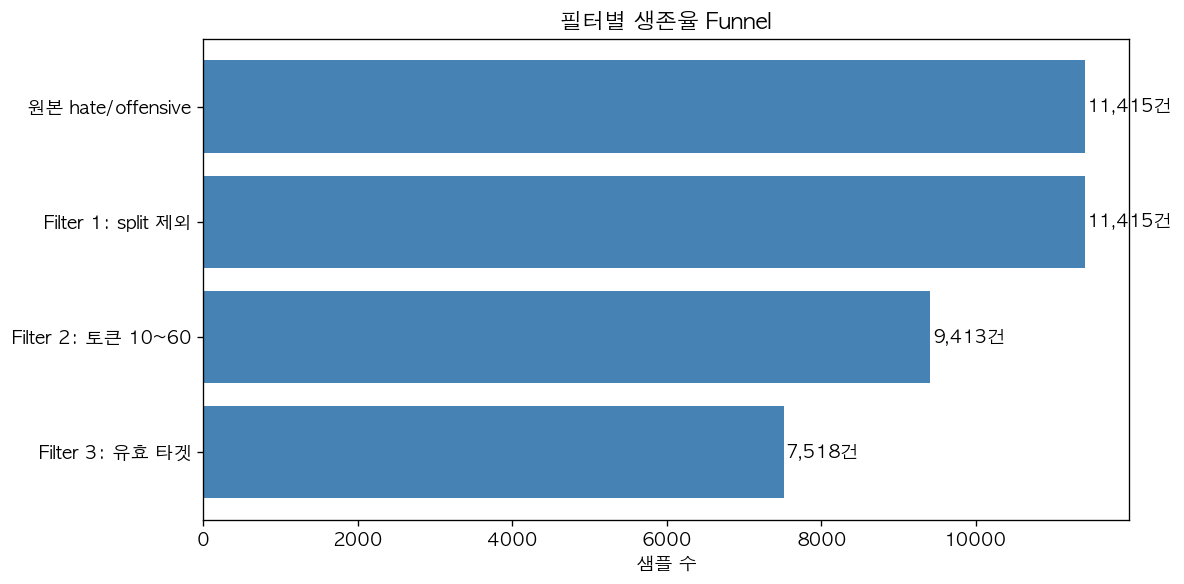

=== 단계별 탈락률 ===
Filter 1: split 제외             | 탈락:    0건 (0.0%)
Filter 2: 토큰 10~60             | 탈락: 2002건 (17.5%)
Filter 3: 유효 타겟                | 탈락: 1895건 (20.1%)


In [94]:
# 단순 버전 — 실제 필터 함수 없이 조건식으로 대체
base = hate_off.copy()

steps = []

# 시작점
steps.append(('원본 hate/offensive', len(base)))

# Filter 1: 3-way split 제외
f1 = base[base['agreement'] != 'split']
steps.append(('Filter 1: split 제외', len(f1)))

# Filter 2: 토큰 수 10~60
f2 = f1[(f1['n_tokens'] >= 10) & (f1['n_tokens'] <= 60)]
steps.append(('Filter 2: 토큰 10~60', len(f2)))

# Filter 3: 유효 타겟 존재
VALID_GROUPS_SET = set(VALID_GROUPS)
f3 = f2[f2['targets_list'].apply(
    lambda ts: len([t for t in ts if t in VALID_GROUPS_SET and t != 'Other']) > 0
    and len([t for t in ts if t != 'Other']) <= 3
)]
steps.append(('Filter 3: 유효 타겟', len(f3)))

step_labels = [s[0] for s in steps]
step_counts = [s[1] for s in steps]

plt.figure(figsize=(10, 5))
bars = plt.barh(step_labels[::-1], step_counts[::-1], color='steelblue')
for bar, count in zip(bars, step_counts[::-1]):
    plt.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             f'{count:,}건', va='center')
plt.title('필터별 생존율 Funnel')
plt.xlabel('샘플 수')
plt.tight_layout()
plt.show()

# 단계별 탈락률
print("=== 단계별 탈락률 ===")
for i in range(1, len(steps)):
    removed = steps[i-1][1] - steps[i][1]
    pct = removed / steps[i-1][1] * 100
    print(f"{steps[i][0]:30s} | 탈락: {removed:4d}건 ({pct:.1f}%)")

In [95]:
print("===== Cell A 초기 분석 요약 체크리스트 =====")
print(f"[1] 전체 샘플 수:                {len(df_raw):>6,}건")
print(f"[2] hate+offensive 샘플:         {len(hate_off):>6,}건 ({len(hate_off)/len(df_raw)*100:.1f}%)")
print(f"[3] unanimous 비율(H/O):         {(hate_off['agreement']=='unanimous').mean()*100:>5.1f}%")
print(f"[4] split 비율(H/O):             {(hate_off['agreement']=='split').mean()*100:>5.1f}%")
print(f"[5] 토큰 10~60 커버리지(H/O):   {len(hate_off[(hate_off.n_tokens>=10)&(hate_off.n_tokens<=60)])/len(hate_off)*100:>5.1f}%")
print(f"[6] VADER compound 평균(hate):   {hate['vader_compound'].mean():>6.3f}")
print(f"[7] VADER compound 평균(off):    {offensive['vader_compound'].mean():>6.3f}")
print(f"[8] 타겟 수 1개인 샘플 비율:     {(hate_off['targets_list'].apply(lambda ts: len([t for t in ts if t in VALID_GROUPS_SET]))==1).mean()*100:.1f}%")
print(f"[9] 타겟 수 3초과 샘플 비율:     {(hate_off['targets_list'].apply(lambda ts: len([t for t in ts if t in VALID_GROUPS_SET]))>3).mean()*100:.1f}%")

===== Cell A 초기 분석 요약 체크리스트 =====
[1] 전체 샘플 수:                19,229건
[2] hate+offensive 샘플:         11,415건 (59.4%)
[3] unanimous 비율(H/O):          41.4%
[4] split 비율(H/O):               0.0%
[5] 토큰 10~60 커버리지(H/O):    82.5%
[6] VADER compound 평균(hate):   -0.358
[7] VADER compound 평균(off):    -0.283
[8] 타겟 수 1개인 샘플 비율:     53.3%
[9] 타겟 수 3초과 샘플 비율:     2.9%


=== 라벨별 NRC 감정 평균 카운트 ===
            anger  disgust   fear  sadness    joy  trust  surprise  \
label                                                                
hatespeech  0.693    0.654  0.778    0.653  0.373  0.598     0.272   
offensive   0.680    0.695  0.807    0.712  0.351  0.563     0.226   

            anticipation  
label                     
hatespeech         0.442  
offensive          0.395  


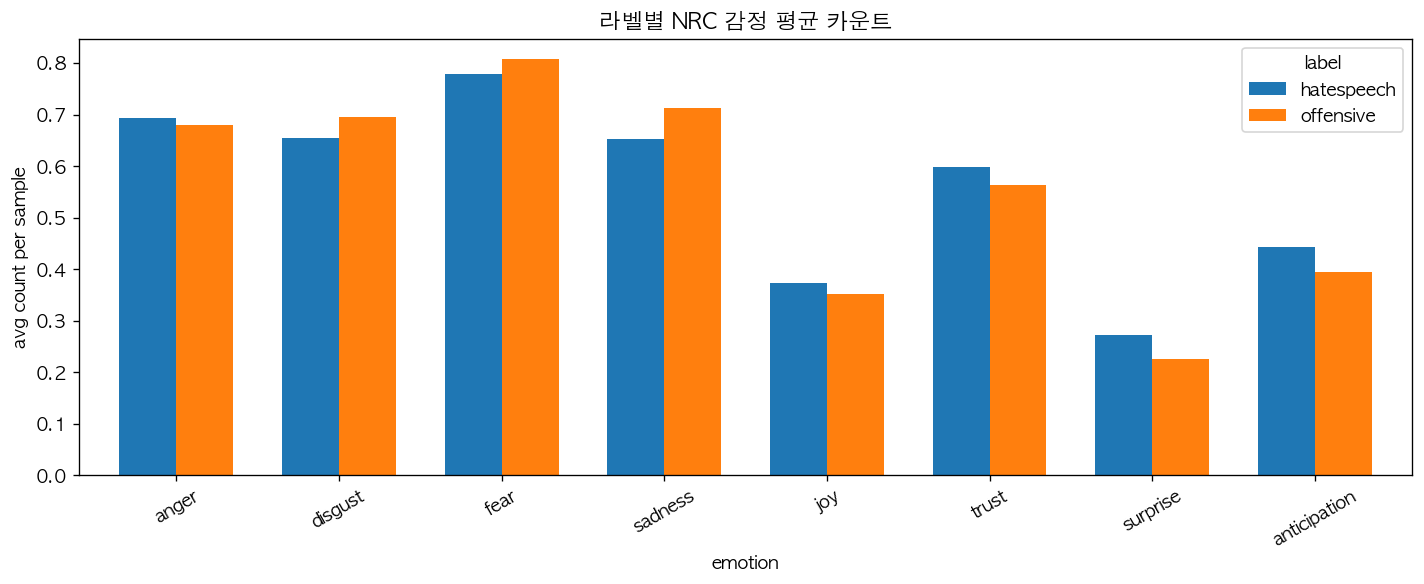


=== neg_cue_sum 라벨별 평균 ===
label
hatespeech    2.125
offensive     2.182
Name: neg_cue_sum, dtype: float64

=== neg_cue_sum × unanimous 상관 (Spearman) ===
SignificanceResult(statistic=np.float64(-0.015694369866507855), pvalue=np.float64(0.09359688506698768))


In [96]:
nrc = pd.read_csv('NRC-Emotion-Lexicon/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt',
                  sep='\t', header=None, names=['word', 'emotion', 'association'])
nrc_pos = nrc[nrc['association'] == 1]
nrc_dict = nrc_pos.groupby('word')['emotion'].apply(list).to_dict()

EMOTIONS = ['anger', 'disgust', 'fear', 'sadness', 'joy', 'trust', 'surprise', 'anticipation']

def count_emotions(tokens):
    counts = Counter()
    for tok in tokens:
        for emo in nrc_dict.get(tok, []):
            counts[emo] += 1
    return counts

analysis_df = hate_off.copy().reset_index(drop=True)
analysis_df['tokens_lower'] = analysis_df['tokens_list'].apply(
    lambda ts: [t.lower() for t in ts]
)

emo_rows = []
for _, row in analysis_df.iterrows():
    c = {emo: 0 for emo in EMOTIONS}  # 먼저 0으로 초기화 → 컬럼 누락 방지
    c.update(count_emotions(row['tokens_lower']))
    c['label'] = row['majority_label']
    emo_rows.append(c)
emo_df = pd.DataFrame(emo_rows).fillna(0)

print("=== 라벨별 NRC 감정 평균 카운트 ===")
print(emo_df.groupby('label')[EMOTIONS].mean().round(3))

# 시각화
emo_means = emo_df.groupby('label')[EMOTIONS].mean()
emo_means.T.plot(kind='bar', figsize=(12, 5), width=0.7)
plt.title('라벨별 NRC 감정 평균 카운트')
plt.xlabel('emotion')
plt.ylabel('avg count per sample')
plt.xticks(rotation=30)
plt.legend(title='label')
plt.tight_layout()
plt.show()

# anger+disgust+fear 합산 (polarity cue 강도 지표)
emo_df['neg_cue_sum'] = emo_df['anger'] + emo_df['disgust'] + emo_df['fear']
print("\n=== neg_cue_sum 라벨별 평균 ===")
print(emo_df.groupby('label')['neg_cue_sum'].mean().round(3))

# unanimous 여부와의 관계
emo_df['unanimous'] = (analysis_df['agreement'] == 'unanimous').astype(int)
print("\n=== neg_cue_sum × unanimous 상관 (Spearman) ===")
print(stats.spearmanr(emo_df['neg_cue_sum'], emo_df['unanimous']))

=== 전체 슬러 포함 비율 ===
slur 있는 샘플: 8982 (78.7%)

=== 타겟별 슬러 포함 비율 ===
            has_slur_rate  avg_slur_density
target                                     
Jewish              0.955             0.108
African             0.905             0.107
Homosexual          0.889             0.104
Asian               0.789             0.083
Arab                0.756             0.070
Women               0.688             0.067
Islam               0.665             0.054
Refugee             0.628             0.046


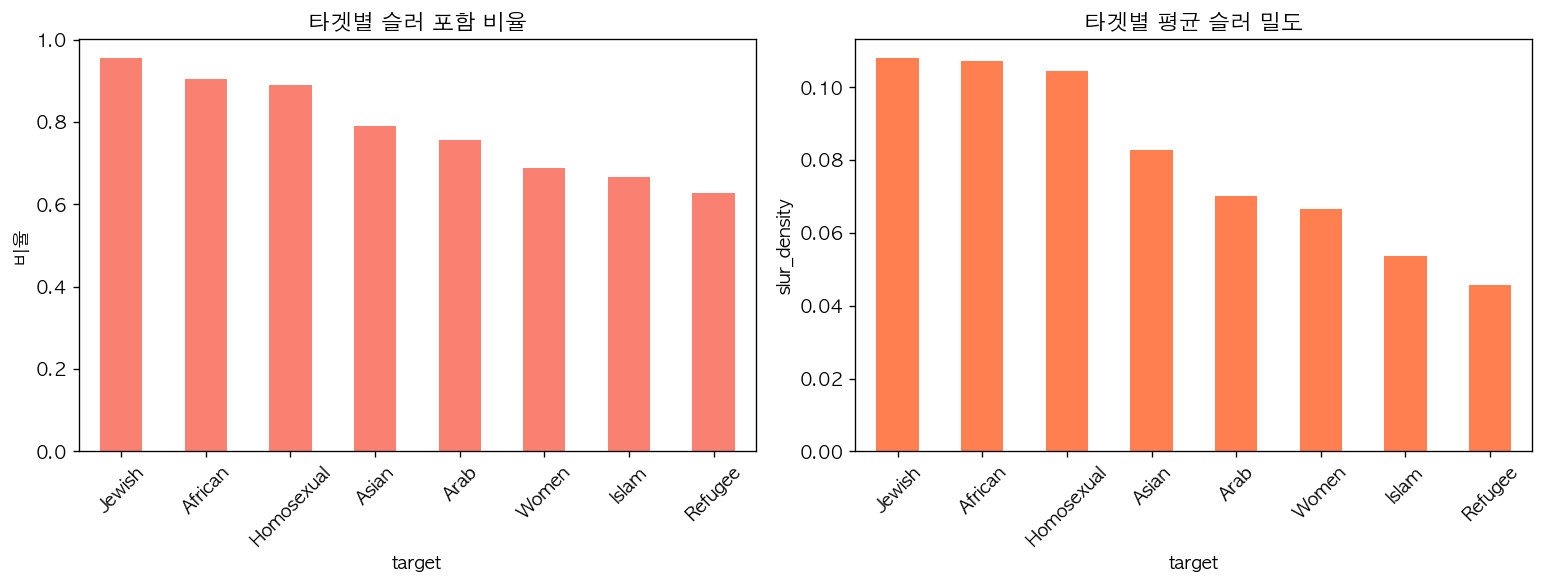


=== 슬러 밀도 vs. label 상관 (Spearman) ===
SignificanceResult(statistic=np.float64(0.18212198626360618), pvalue=np.float64(1.0381707744419271e-85))


In [97]:
hurtlex = pd.read_csv('lexicons/hurtlex_EN.tsv', sep='\t')
TARGET_CATS = {'ps', 'rci', 'ddp', 'or', 'gi', 'qas', 're'}
slur_base = set(hurtlex[hurtlex['category'].isin(TARGET_CATS)]['lemma'].str.lower())

SLUR_SET = set(slur_base)
for s in list(slur_base):
    SLUR_SET.update({s+'s', s+'es', s+'z', s+'er', s+'ers', s+'ing', s+'ed'})

def slur_density(tokens):
    slurs = [t for t in tokens if t in SLUR_SET]
    return len(slurs) / max(len(tokens), 1)

analysis_df['slur_count'] = analysis_df['tokens_lower'].apply(
    lambda ts: len([t for t in ts if t in SLUR_SET])
)
analysis_df['slur_density'] = analysis_df.apply(
    lambda row: slur_density(row['tokens_lower']), axis=1
)
analysis_df['has_slur'] = analysis_df['slur_count'] > 0

print("=== 전체 슬러 포함 비율 ===")
print(f"slur 있는 샘플: {analysis_df['has_slur'].sum()} ({analysis_df['has_slur'].mean()*100:.1f}%)")

# 타겟별 슬러 밀도
slur_target_rows = []
for _, row in analysis_df.iterrows():
    for t in set(row['targets_list']):
        if t in VALID_GROUPS:
            slur_target_rows.append({
                'target': t,
                'slur_density': row['slur_density'],
                'has_slur': row['has_slur'],
                'label': row['majority_label']
            })
st_df = pd.DataFrame(slur_target_rows)

print("\n=== 타겟별 슬러 포함 비율 ===")
slur_by_target = st_df.groupby('target').agg(
    has_slur_rate=('has_slur', 'mean'),
    avg_slur_density=('slur_density', 'mean')
).sort_values('has_slur_rate', ascending=False)
print(slur_by_target.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
slur_by_target['has_slur_rate'].plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('타겟별 슬러 포함 비율')
axes[0].set_ylabel('비율')
axes[0].tick_params(axis='x', rotation=45)

slur_by_target['avg_slur_density'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('타겟별 평균 슬러 밀도')
axes[1].set_ylabel('slur_density')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# 슬러 전용 샘플 (non_slur_cue = 0) 비율 예측
# 실제 Filter 5는 non_slur_cue >= 1 이므로, slur_only 비율이 높으면 많이 탈락
print("\n=== 슬러 밀도 vs. label 상관 (Spearman) ===")
print(stats.spearmanr(analysis_df['slur_density'],
                      analysis_df['majority_label'].map({'hatespeech':1,'offensive':0})))

NONE_DETECTED 비율: 59.6%

=== 프레이밍 빈도 ===
NONE_DETECTED               6806
INTELLECTUAL_INFERIORITY    1460
CRIMINAL_DANGER              943
THREAT_VIOLENCE              865
SEXUAL_GENDERED              819
DEHUMANIZATION               387
MORAL_DISGUST                380
CONSPIRACY                   350
GENERALIZATION               176
ECONOMIC_BURDEN              170
RELIGIOUS                    149
EXCLUSION                    144
dtype: int64


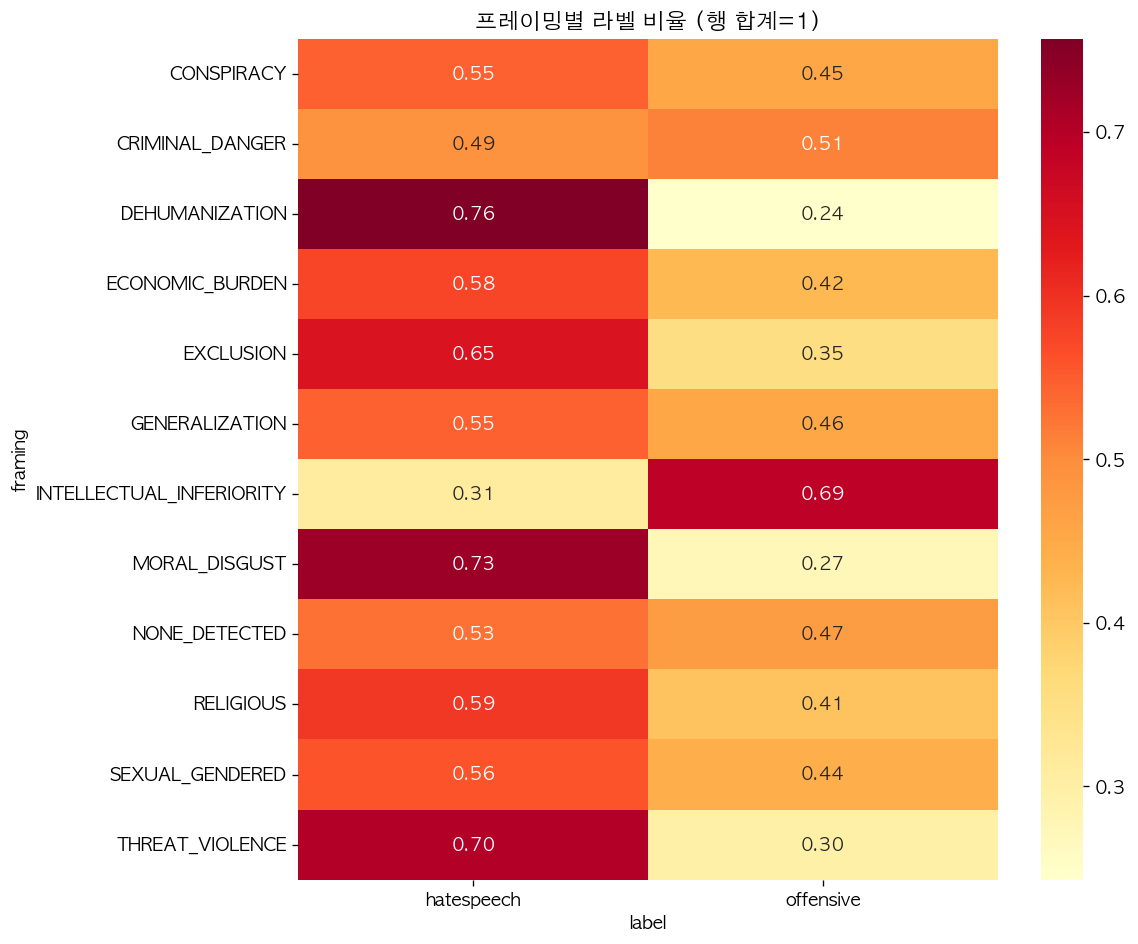

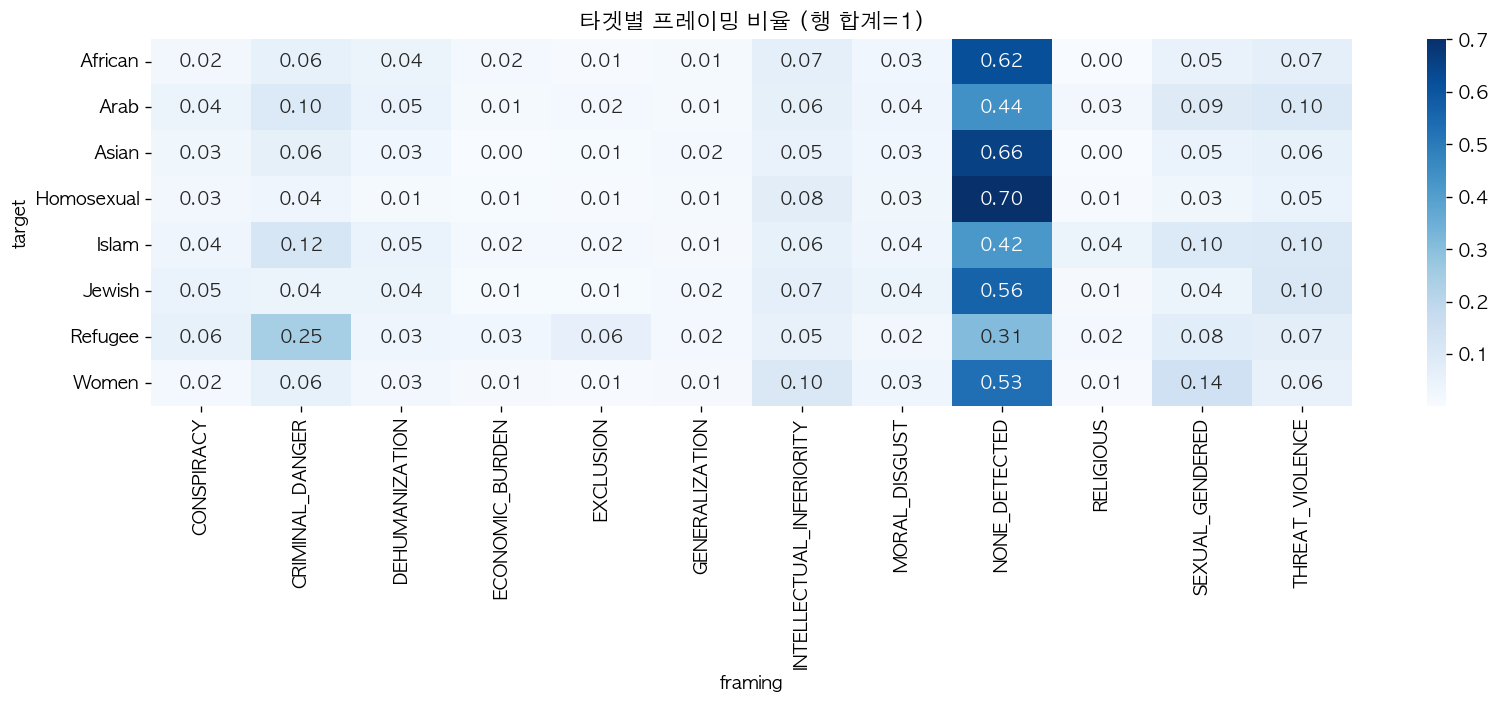

In [98]:
import re

FRAMING_LEXICONS = {
    'DEHUMANIZATION': {'keywords': ['animal','animals','monkey','monkeys','ape','apes','cockroach','cockroaches',
                                    'vermin','pest','pests','rat','rats','subhuman','savage','savages',
                                    'parasite','parasites','infestation','infest','plague','filth','scum']},
    'THREAT_VIOLENCE': {'keywords': ['kill','killed','hang','gas','shoot','bomb','nuke','exterminate',
                                     'execute','lynch','murder','slaughter','purge','cleanse','eradicate',
                                     'eliminate','burn','stab','genocide','holocaust','die','death','dead']},
    'EXCLUSION': {'patterns': [r'\bgo back\b',r"\bdon't belong\b",r'\bnot welcome\b',r'\bget out\b',
                               r'\bsend back\b',r'\bdeport\b',r'\bkick out\b',r'\bkeep out\b',
                               r'\bban\b.*\bmuslim\b',r'\bbuild\b.*\bwall\b',r'\billegal alien\b']},
    'CONSPIRACY': {'keywords': ['control','controls','controlling','destroy','destroying','invasion','invade',
                                'replace','replacing','replacement','overthrow','infiltrate','conspire',
                                'conspiracy','plot','scheme','agenda','globalist','puppet','brainwash',
                                'propaganda','takeover','manipulate']},
    'MORAL_DISGUST': {'keywords': ['disgusting','disgust','filthy','dirty','unclean','impure','immoral',
                                   'degenerate','degenerates','pervert','perverted','abomination','sick',
                                   'sickening','vile','repulsive','revolting','sinful','unholy','gross']},
    'INTELLECTUAL_INFERIORITY': {'keywords': ['stupid','dumb','idiot','idiots','idiotic','moron','morons',
                                              'imbecile','brainless','uneducated','illiterate','ignorant',
                                              'retarded','retard','braindead','clueless','incompetent',
                                              'dense','fool','fools','mindless']},
    'SEXUAL_GENDERED': {'keywords': ['rape','raped','raping','rapist','rapists','breed','breeding',
                                     'molest','molested','slut','sluts','whore','whores','hoe','thot']},
    'CRIMINAL_DANGER': {'keywords': ['crime','criminal','criminals','thug','thugs','gang','gangs',
                                     'terrorist','terrorists','terrorism','steal','stealing','theft',
                                     'thief','thieves','rob','robbery','illegal','illegals','felon',
                                     'pedophile','pedophiles','predator','danger','dangerous','threat',
                                     'violent','violence','radical']},
    'ECONOMIC_BURDEN': {'keywords': ['welfare','leech','leeches','freeloader','freeloaders','parasite',
                                     'taxpayer','taxpayers','burden','lazy','handout','handouts','mooch',
                                     'tax','taxes','benefits']},
    'RELIGIOUS': {'keywords': ['jihad','jihadi','sharia','infidel','infidels','islamist','heathen',
                               'godless','blasphemy','blasphemous','satanic','satan','antichrist','crusade']},
    'GENERALIZATION': {'patterns': [r'\ball\b.{0,30}\bare\b',r'\ball\b.{0,30}\bdo\b',
                                    r'\bevery\b.{0,30}\bis\b',r'\bevery\b.{0,30}\bdoes\b']},
}

def classify_framing(text, toks):
    tok_set = set(toks)
    frames = []
    for label, cfg in FRAMING_LEXICONS.items():
        matched = False
        if 'keywords' in cfg and tok_set & set(cfg['keywords']):
            matched = True
        if not matched and 'patterns' in cfg:
            for pat in cfg['patterns']:
                if re.search(pat, text, re.IGNORECASE):
                    matched = True
                    break
        if matched:
            frames.append(label)
    return frames if frames else ['NONE_DETECTED']

analysis_df['text'] = analysis_df['tokens_lower'].apply(lambda ts: ' '.join(ts))
analysis_df['framing'] = analysis_df.apply(
    lambda row: classify_framing(row['text'], row['tokens_lower']), axis=1
)
analysis_df['primary_framing'] = analysis_df['framing'].apply(lambda fs: fs[0])
analysis_df['n_framings'] = analysis_df['framing'].apply(len)
analysis_df['has_framing'] = analysis_df['primary_framing'] != 'NONE_DETECTED'

print(f"NONE_DETECTED 비율: {(~analysis_df['has_framing']).mean()*100:.1f}%")

# 프레이밍 빈도
all_frames = [f for fs in analysis_df['framing'] for f in fs]
print("\n=== 프레이밍 빈도 ===")
print(pd.Series(Counter(all_frames)).sort_values(ascending=False))

# 라벨별 프레이밍 분포 heatmap
frame_label_rows = []
for _, row in analysis_df.iterrows():
    for f in set(row['framing']):
        frame_label_rows.append({'framing': f, 'label': row['majority_label']})
fl_df = pd.DataFrame(frame_label_rows)
fl_pivot = pd.crosstab(fl_df['framing'], fl_df['label'], normalize='index').round(3)

plt.figure(figsize=(10, 8))
sns.heatmap(fl_pivot, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('프레이밍별 라벨 비율 (행 합계=1)')
plt.tight_layout()
plt.show()

# 타겟별 주요 프레이밍 분포
frame_target_rows = []
for _, row in analysis_df.iterrows():
    for t in set(row['targets_list']):
        if t in VALID_GROUPS:
            for f in set(row['framing']):
                frame_target_rows.append({'target': t, 'framing': f})
ft_df = pd.DataFrame(frame_target_rows)
ft_pivot = pd.crosstab(ft_df['target'], ft_df['framing'])
ft_pivot_pct = ft_pivot.div(ft_pivot.sum(axis=1), axis=0).round(3)

plt.figure(figsize=(14, 6))
sns.heatmap(ft_pivot_pct, annot=True, fmt='.2f', cmap='Blues')
plt.title('타겟별 프레이밍 비율 (행 합계=1)')
plt.tight_layout()
plt.show()

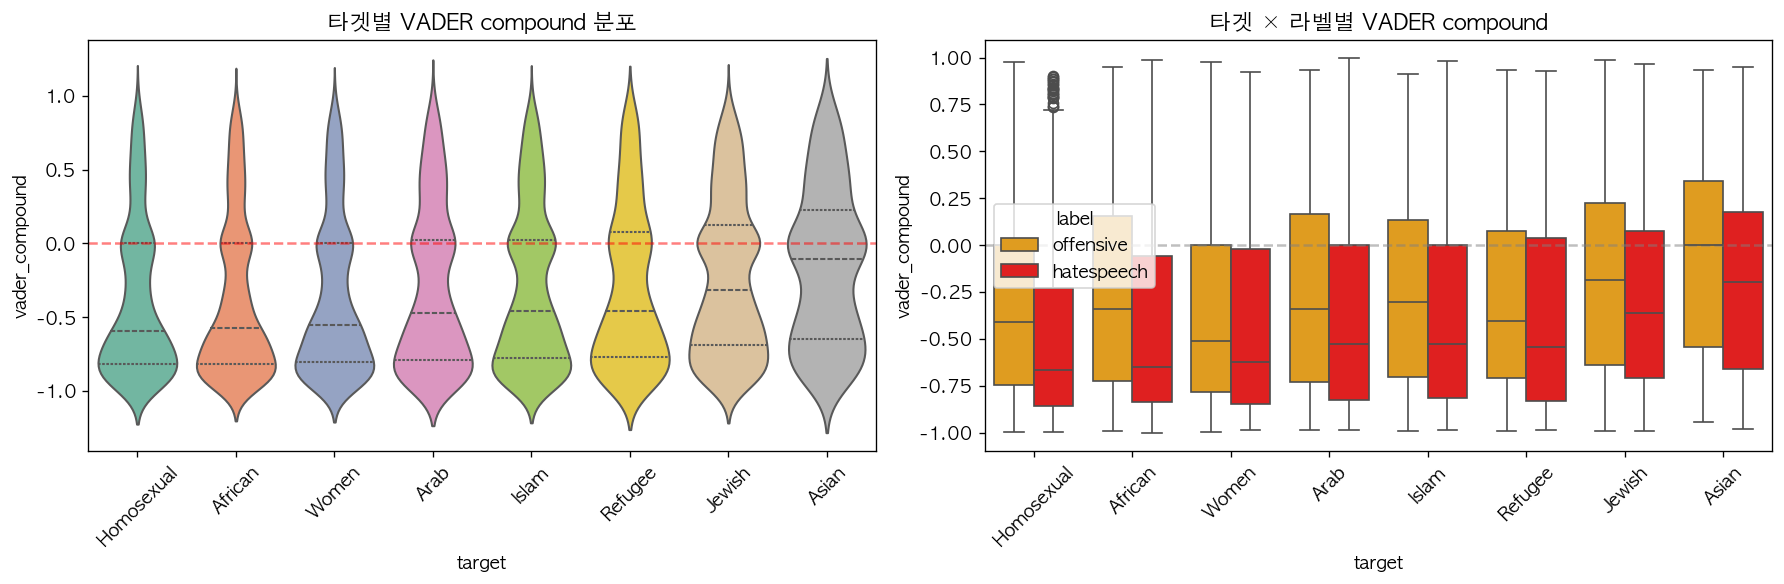

=== 타겟별 VADER compound 중앙값 ===
target
Homosexual   -0.592
African      -0.576
Women        -0.553
Arab         -0.471
Islam        -0.459
Refugee      -0.459
Jewish       -0.318
Asian        -0.103
Name: vader_compound, dtype: float64


In [99]:
vader_target_rows = []
for _, row in analysis_df.iterrows():
    compound = vader.polarity_scores(row['text'])['compound']
    for t in set(row['targets_list']):
        if t in VALID_GROUPS:
            vader_target_rows.append({'target': t, 'vader_compound': compound,
                                      'label': row['majority_label']})
vt_df = pd.DataFrame(vader_target_rows)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Violin plot — 전체
order = vt_df.groupby('target')['vader_compound'].median().sort_values().index.tolist()
sns.violinplot(data=vt_df, x='target', y='vader_compound', order=order,
               ax=axes[0], palette='Set2', inner='quartile')
axes[0].set_title('타겟별 VADER compound 분포')
axes[0].set_xticklabels(order, rotation=45)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)

# Box plot — hatespeech vs offensive 분리
sns.boxplot(data=vt_df, x='target', y='vader_compound', hue='label',
            order=order, ax=axes[1], palette={'hatespeech': 'red', 'offensive': 'orange'})
axes[1].set_title('타겟 × 라벨별 VADER compound')
axes[1].set_xticklabels(order, rotation=45)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("=== 타겟별 VADER compound 중앙값 ===")
print(vt_df.groupby('target')['vader_compound'].median().sort_values().round(3))

=== OLS: hatespeech 예측 ===
R² = 0.059
        feature    coef  p_value sig
          const  0.3628   0.0000 ***
       n_tokens  0.0037   0.0000 ***
      n_targets  0.0084   0.0380   *
      vader_neg -0.2180   0.0000 ***
 vader_compound -0.0697   0.0000 ***
   slur_density  1.2471   0.0000 ***
     n_framings -0.0419   0.0031  **
 generalization  0.0071   0.8494    
      exclusion  0.1571   0.0001 ***
 dehumanization  0.1967   0.0000 ***
threat_violence  0.1688   0.0000 ***

=== OLS: unanimous 예측 ===
R² = 0.027
        feature    coef  p_value sig
          const  0.4460   0.0000 ***
       n_tokens -0.0003   0.3978    
      n_targets -0.0421   0.0000 ***
      vader_neg  0.0954   0.0228   *
 vader_compound -0.0267   0.0395   *
   slur_density  0.4963   0.0000 ***
     n_framings -0.0192   0.1758    
 generalization  0.0435   0.2484    
      exclusion  0.0178   0.6688    
 dehumanization  0.1280   0.0000 ***
threat_violence  0.0398   0.0306   *


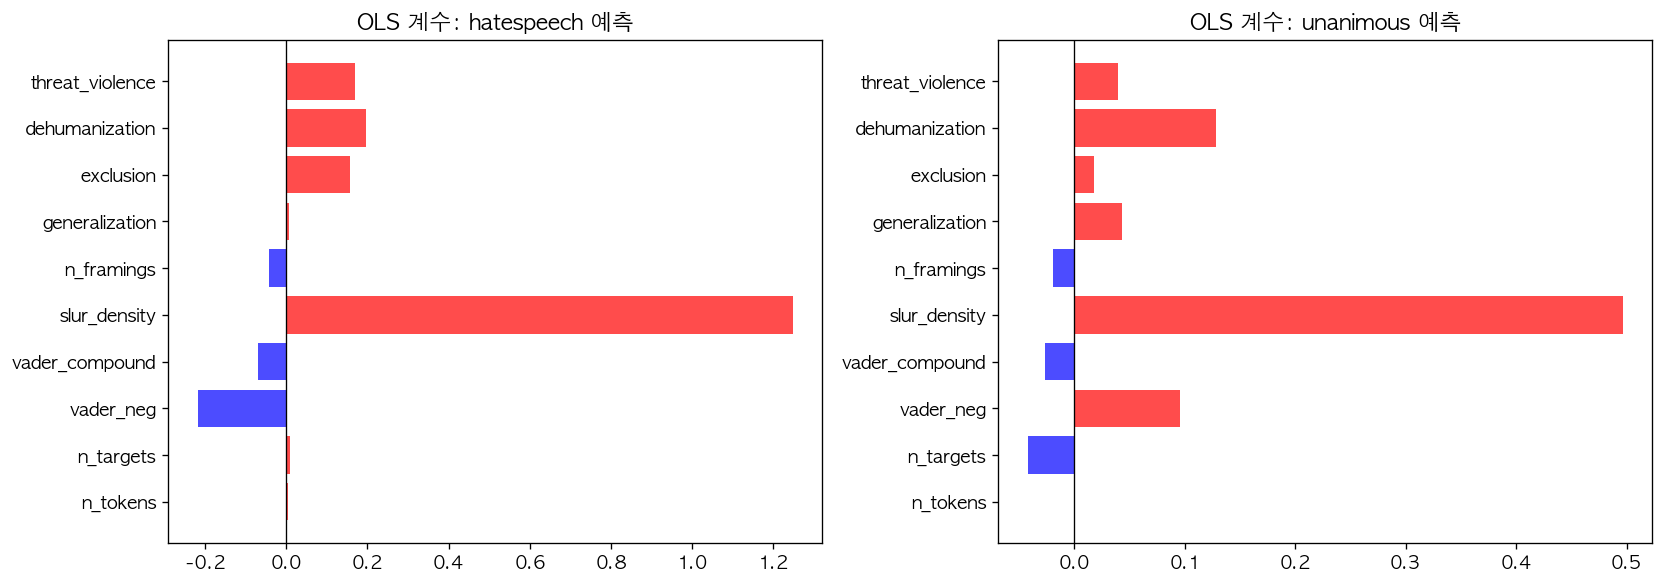

In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import statsmodels.api as sm

# 특성 구성
reg_df = analysis_df.copy()

# n_targets: Cell 10에서 만든 analysis_df에 없을 수 있으므로 여기서 추가
if 'n_targets' not in reg_df.columns:
    reg_df['n_targets'] = reg_df['targets_list'].apply(
        lambda ts: len([t for t in ts if t != 'Other'])
    )

reg_df['vader_neg'] = reg_df['text'].apply(lambda t: vader.polarity_scores(t)['neg'])
reg_df['vader_compound'] = reg_df['text'].apply(lambda t: vader.polarity_scores(t)['compound'])
reg_df['label_binary'] = (reg_df['majority_label'] == 'hatespeech').astype(int)
reg_df['unanimous'] = (reg_df['agreement'] == 'unanimous').astype(int)
reg_df['generalization'] = reg_df['framing'].apply(lambda fs: int('GENERALIZATION' in fs))
reg_df['exclusion'] = reg_df['framing'].apply(lambda fs: int('EXCLUSION' in fs))
reg_df['dehumanization'] = reg_df['framing'].apply(lambda fs: int('DEHUMANIZATION' in fs))
reg_df['threat_violence'] = reg_df['framing'].apply(lambda fs: int('THREAT_VIOLENCE' in fs))

FEATURES = ['n_tokens', 'n_targets', 'vader_neg', 'vader_compound',
            'slur_density', 'n_framings',
            'generalization', 'exclusion', 'dehumanization', 'threat_violence']

X = reg_df[FEATURES].values
y_label = reg_df['label_binary'].values
y_agree = reg_df['unanimous'].values

# OLS: hatespeech 예측
X_const = sm.add_constant(X)
ols_label = sm.OLS(y_label, X_const).fit()
print("=== OLS: hatespeech 예측 ===")
print(f"R² = {ols_label.rsquared:.3f}")
result_df = pd.DataFrame({
    'feature': ['const'] + FEATURES,
    'coef': ols_label.params.round(4),
    'p_value': ols_label.pvalues.round(4)
})
result_df['sig'] = result_df['p_value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
)
print(result_df.to_string(index=False))

# OLS: unanimous 예측
ols_agree = sm.OLS(y_agree, X_const).fit()
print("\n=== OLS: unanimous 예측 ===")
print(f"R² = {ols_agree.rsquared:.3f}")
result_agree = pd.DataFrame({
    'feature': ['const'] + FEATURES,
    'coef': ols_agree.params.round(4),
    'p_value': ols_agree.pvalues.round(4)
})
result_agree['sig'] = result_agree['p_value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
)
print(result_agree.to_string(index=False))

# 계수 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, result, title in zip(
    axes,
    [result_df[result_df['feature'] != 'const'], result_agree[result_agree['feature'] != 'const']],
    ['OLS 계수: hatespeech 예측', 'OLS 계수: unanimous 예측']
):
    colors = ['red' if c > 0 else 'blue' for c in result['coef']]
    ax.barh(result['feature'], result['coef'], color=colors, alpha=0.7)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title)
plt.tight_layout()
plt.show()

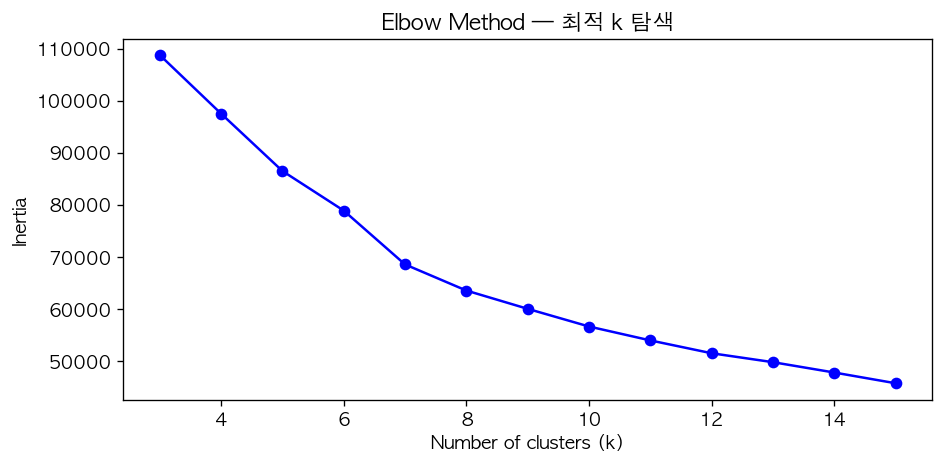

=== 클러스터별 특성 요약 ===
         n_tokens  n_targets  slur_density  vader_neg  vader_compound  n_framings  label_binary  unanimous  generalization  exclusion  dehumanization  threat_violence
cluster                                                                                                                                                               
0          29.597      2.117         0.069      0.230          -0.597       1.084         0.999      0.489             0.0        0.0           0.000            0.000
1           9.152      1.638         0.213      0.473          -0.648       1.033         0.641      0.573             0.0        0.0           0.000            0.005
2          24.531      1.860         0.054      0.261          -0.594       1.057         0.000      0.304             0.0        0.0           0.000            0.000
3          21.587      1.941         0.055      0.044           0.324       1.010         0.443      0.352             0.0        0.0           0

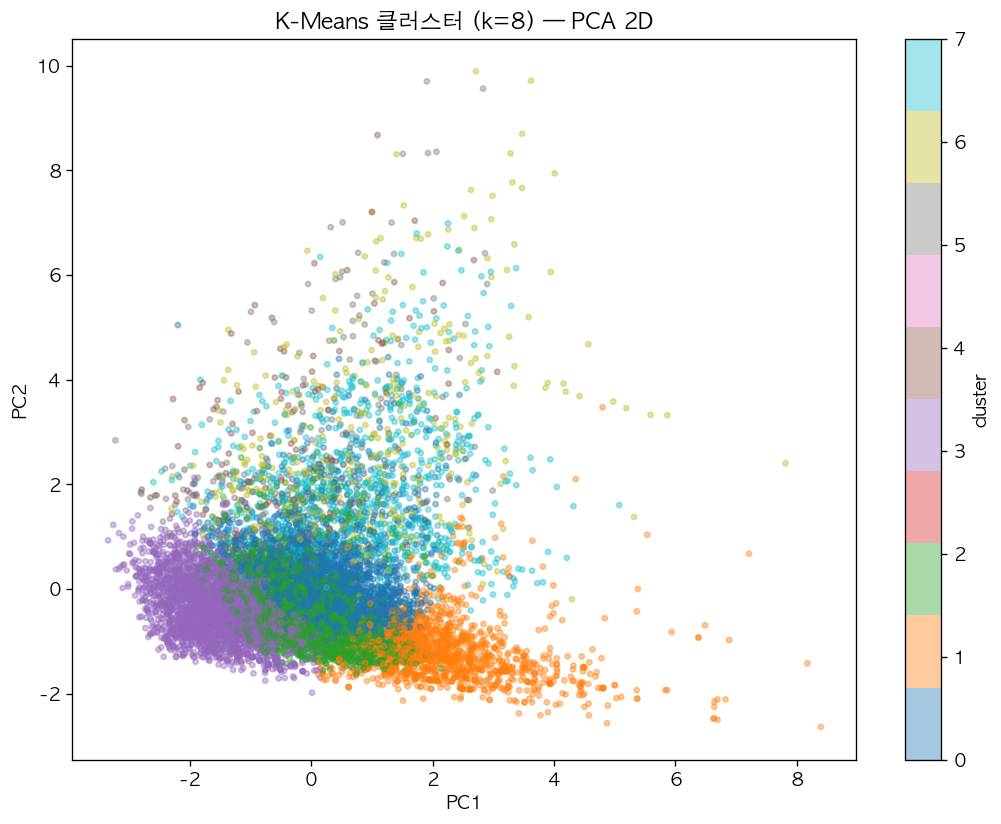


=== 클러스터별 대표 샘플 ===

[Cluster 0] (n=2536, hate=1.00, vader=-0.60)
  [hatespeech] i do not want to look like a snow nigger that easily prone to skin cancer anyway
  [hatespeech] do you remember when you could go out in public in europe without being sexually
  [hatespeech] you looked like an old road whore hag back then i can only imagine how well you 

[Cluster 1] (n=1498, hate=0.64, vader=-0.65)
  [hatespeech] better believe the kikes are behind these nigger attacks
  [hatespeech] you niggas faggots putting you all hands on females
  [hatespeech] lol only a female nigger could be so dumb

[Cluster 2] (n=2686, hate=0.00, vader=-0.59)
  [offensive] agreed folk i did not realize there were optics cucks among us lol sad too much 
  [offensive] <user> tbh i am so happy cause bitch done lost her stylus months ago and that sh
  [offensive] <number> <number> friendly corpses later <number> thousand of our people wrecked

[Cluster 3] (n=3224, hate=0.44, vader=0.32)
  [offensive] hey you bigot

In [101]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

cluster_features = [
    'n_tokens', 'n_targets', 'slur_density',
    'vader_neg', 'vader_compound', 'n_framings',
    'label_binary', 'unanimous',
    'generalization', 'exclusion', 'dehumanization', 'threat_violence'
]

X_cluster = reg_df[cluster_features].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method로 최적 k 탐색
inertias = []
K_range = range(3, 16)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — 최적 k 탐색')
plt.tight_layout()
plt.show()

# k=8로 클러스터링
k = 8
km = KMeans(n_clusters=k, random_state=42, n_init=10)
reg_df['cluster'] = km.fit_predict(X_scaled)

# 클러스터별 특성 요약
print("=== 클러스터별 특성 요약 ===")
cluster_summary = reg_df.groupby('cluster')[cluster_features].mean().round(3)
print(cluster_summary.to_string())

# 클러스터별 주요 프레이밍 분포
print("\n=== 클러스터별 샘플 수 + 라벨 비율 ===")
cluster_info = reg_df.groupby('cluster').agg(
    n=('label_binary', 'count'),
    hate_rate=('label_binary', 'mean'),
    unanimous_rate=('unanimous', 'mean'),
    avg_vader=('vader_compound', 'mean'),
    avg_slur_density=('slur_density', 'mean'),
).round(3)
print(cluster_info)

# PCA 2D 시각화
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=reg_df['cluster'], cmap='tab10', alpha=0.4, s=10)
plt.colorbar(scatter, label='cluster')
plt.title(f'K-Means 클러스터 (k={k}) — PCA 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

# 클러스터별 대표 샘플 (각 군집 중심에 가장 가까운 5개)
print("\n=== 클러스터별 대표 샘플 ===")
for c in range(k):
    mask = reg_df['cluster'] == c
    cluster_X = X_scaled[mask]
    center = km.cluster_centers_[c]
    dists = np.linalg.norm(cluster_X - center, axis=1)
    top_idx = np.argsort(dists)[:3]
    samples = reg_df[mask].iloc[top_idx]
    print(f"\n[Cluster {c}] (n={mask.sum()}, hate={cluster_info.loc[c,'hate_rate']:.2f}, vader={cluster_info.loc[c,'avg_vader']:.2f})")
    for _, s in samples.iterrows():
        print(f"  [{s['majority_label']}] {s['text'][:80]}")
    

agreement 분포: {'majority': 6694, 'unanimous': 4721}

=== unanimous vs. majority 특성 비교 ===
n_tokens             | unanimous: 22.559 | majority: 24.180 | p=0.0000 ***
vader_compound       | unanimous: -0.365 | majority: -0.292 | p=0.0000 ***
slur_count           | unanimous: 1.713 | majority: 1.510 | p=0.0000 ***
n_targets            | unanimous: 1.376 | majority: 1.367 | p=0.5008 

=== unanimous 샘플 타겟 분포 ===
[('African', 1667), ('Women', 1079), ('Jewish', 1073), ('Islam', 879), ('Homosexual', 779), ('Arab', 571), ('Refugee', 289), ('Asian', 161)]


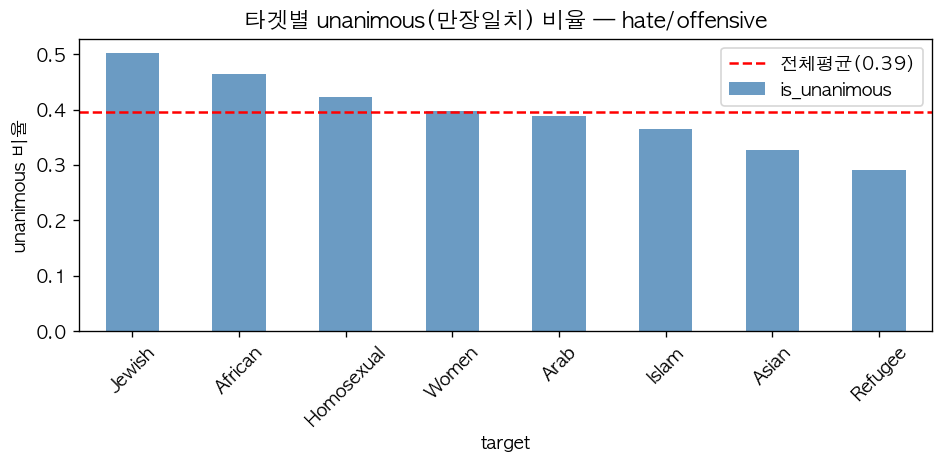

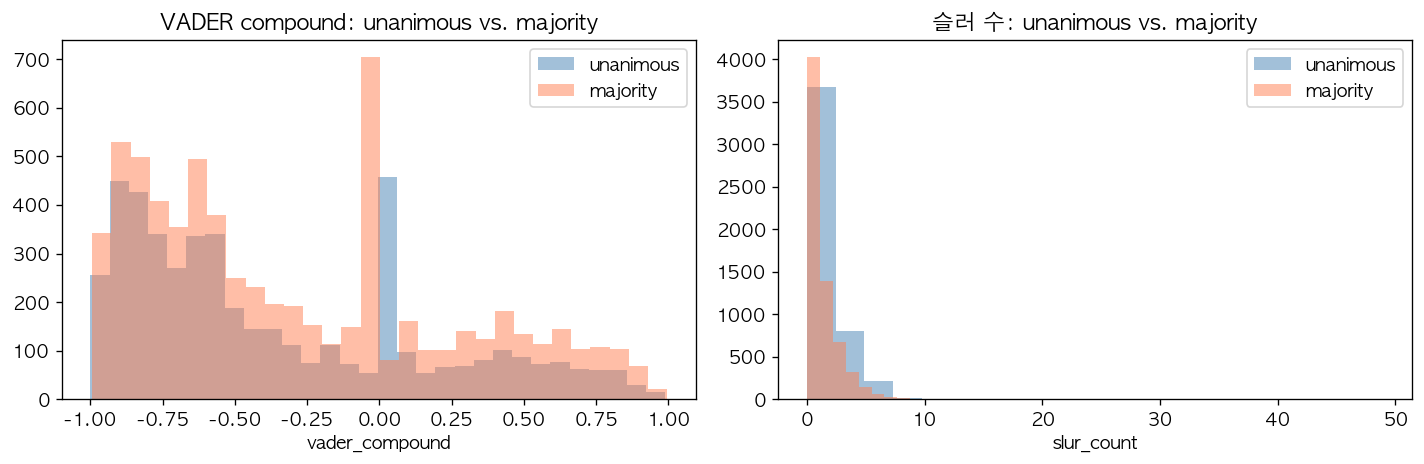

In [102]:
# hate/offensive 중 unanimous vs. majority 비교
all_ho = df_raw[df_raw['majority_label'].isin(['hatespeech', 'offensive'])].copy()
all_ho['tokens_list'] = all_ho['post_tokens'].apply(parse_token_col)
all_ho['tokens_lower'] = all_ho['tokens_list'].apply(lambda ts: [t.lower() for t in ts])
all_ho['n_tokens'] = all_ho['tokens_list'].apply(len)
all_ho['text'] = all_ho['tokens_lower'].apply(lambda ts: ' '.join(ts))
all_ho['vader_compound'] = all_ho['text'].apply(lambda t: vader.polarity_scores(t)['compound'])
all_ho['slur_count'] = all_ho['tokens_lower'].apply(
    lambda ts: len([t for t in ts if t in SLUR_SET])
)
all_ho['targets_list'] = all_ho['targets'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
all_ho['n_targets'] = all_ho['targets_list'].apply(
    lambda ts: len([t for t in ts if t in VALID_GROUPS])
)

print(f"agreement 분포: {all_ho['agreement'].value_counts().to_dict()}")

unan_group = all_ho[all_ho['agreement'] == 'unanimous']
majority_group = all_ho[all_ho['agreement'] == 'majority']

print("\n=== unanimous vs. majority 특성 비교 ===")
for col in ['n_tokens', 'vader_compound', 'slur_count', 'n_targets']:
    t_stat, p_val = stats.mannwhitneyu(unan_group[col], majority_group[col], alternative='two-sided')
    print(f"{col:20s} | unanimous: {unan_group[col].mean():.3f} | majority: {majority_group[col].mean():.3f} "
          f"| p={p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''}")

# unanimous 샘플의 타겟 분포
unan_targets = [t for ts in unan_group['targets_list'] for t in ts if t in VALID_GROUPS]
print("\n=== unanimous 샘플 타겟 분포 ===")
print(Counter(unan_targets).most_common())

# 타겟별 unanimous 비율
all_ho_exploded = []
for _, row in all_ho.iterrows():
    for t in set(row['targets_list']):
        if t in VALID_GROUPS:
            all_ho_exploded.append({'target': t, 'is_unanimous': int(row['agreement'] == 'unanimous')})
exploded_df = pd.DataFrame(all_ho_exploded)
unan_rate_by_target = exploded_df.groupby('target')['is_unanimous'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
unan_rate_by_target.plot(kind='bar', color='steelblue', alpha=0.8)
plt.axhline(unan_rate_by_target.mean(), color='red', linestyle='--',
            label=f'전체평균({unan_rate_by_target.mean():.2f})')
plt.title('타겟별 unanimous(만장일치) 비율 — hate/offensive')
plt.ylabel('unanimous 비율')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# vader_compound 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for group, label, color in [(unan_group, 'unanimous', 'steelblue'),
                             (majority_group, 'majority', 'coral')]:
    axes[0].hist(group['vader_compound'], bins=30, alpha=0.5, label=label, color=color)
axes[0].set_title('VADER compound: unanimous vs. majority')
axes[0].legend()
axes[0].set_xlabel('vader_compound')

for group, label, color in [(unan_group, 'unanimous', 'steelblue'),
                             (majority_group, 'majority', 'coral')]:
    axes[1].hist(group['slur_count'], bins=20, alpha=0.5, label=label, color=color)
axes[1].set_title('슬러 수: unanimous vs. majority')
axes[1].legend()
axes[1].set_xlabel('slur_count')
plt.tight_layout()
plt.show()

In [103]:
print("========== HateXplain 초기 EDA 최종 요약 ==========")
print(f"[데이터] 전체: {len(df_raw):,}건 | hate/off: {len(analysis_df):,}건")
print(f"[Agreement] unanimous: {(analysis_df['agreement']=='unanimous').mean()*100:.1f}% "
      f"| split: {(analysis_df['agreement']=='split').mean()*100:.1f}%")
print(f"[토큰] 중앙값: {analysis_df['n_tokens'].median():.0f} | 10~60 커버리지: "
      f"{((analysis_df.n_tokens>=10)&(analysis_df.n_tokens<=60)).mean()*100:.1f}%")
print(f"[슬러] 포함 비율: {analysis_df['has_slur'].mean()*100:.1f}% "
      f"| 평균 밀도: {analysis_df['slur_density'].mean():.3f}")
# vader_compound는 reg_df에 있음 (analysis_df에는 없을 수 있음)
_vader_hate = reg_df[reg_df.majority_label=='hatespeech']['vader_compound'].mean()
_vader_off  = reg_df[reg_df.majority_label=='offensive']['vader_compound'].mean()
print(f"[VADER] hate 평균: {_vader_hate:.3f} | offensive 평균: {_vader_off:.3f}")
print(f"[프레이밍] NONE_DETECTED: {(~analysis_df['has_framing']).mean()*100:.1f}% "
      f"| 복합 프레이밍(2개↑): {(analysis_df['n_framings']>=2).mean()*100:.1f}%")
print(f"[OLS R²] hatespeech 예측: {ols_label.rsquared:.3f} "
      f"| unanimous 예측: {ols_agree.rsquared:.3f}")
print(f"[클러스터] k={k}으로 분류됨")

========== HateXplain 초기 EDA 최종 요약 ==========
[데이터] 전체: 19,229건 | hate/off: 11,415건
[Agreement] unanimous: 41.4% | split: 0.0%
[토큰] 중앙값: 21 | 10~60 커버리지: 82.5%
[슬러] 포함 비율: 78.7% | 평균 밀도: 0.083
[VADER] hate 평균: -0.358 | offensive 평균: -0.283
[프레이밍] NONE_DETECTED: 59.6% | 복합 프레이밍(2개↑): 8.8%
[OLS R²] hatespeech 예측: 0.059 | unanimous 예측: 0.027
[클러스터] k=8으로 분류됨


In [104]:
print("df_raw agreement 분포:")
print(df_raw['agreement'].value_counts())

print("\nall_ho agreement 분포:")
print(all_ho['agreement'].value_counts())

df_raw agreement 분포:
agreement
unanimous    9845
majority     9384
Name: count, dtype: int64

all_ho agreement 분포:
agreement
majority     6694
unanimous    4721
Name: count, dtype: int64
